# 02 Phase 2 Evaluation Notebook

This notebook evaluates a saved `MyAgeClassifier (Phase 2 / strong regularization)` checkpoint on a public age-labeled face benchmark and exports:
- metrics
- predictions
- confidence analysis
- calibration
- age-bucket performance
- robustness tests
- latency
- qualitative error analysis

In [1]:
!pip -q install datasets scikit-learn seaborn pandas matplotlib pillow tqdm

In [2]:
import os, json, math, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
    log_loss,
)
from sklearn.calibration import calibration_curve

from datasets import load_dataset

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [3]:
MODEL_PATH = "/content/part2.pth"
OUTPUT_DIR = Path("/content/phase2_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

AGE_THRESHOLD = 30   # young if age < 30 else old
MAX_SAMPLES = 1000   # set None to use full dataset if internet/ram allow
BATCH_SIZE = 64

print("MODEL_PATH:", MODEL_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

MODEL_PATH: /content/part2.pth
OUTPUT_DIR: /content/phase2_outputs


In [4]:
class MyAgeClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.BatchNorm1d(num_ftrs),
            nn.Dropout(0.4),
            nn.Linear(num_ftrs, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        if self.training:
            return self.backbone(x)
        out_original = self.backbone(x)
        out_flipped = self.backbone(torch.flip(x, dims=[3]))
        return (out_original + out_flipped) / 2.0

In [5]:
def safe_torch_load(path, device="cpu"):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def age_to_label(age):
    return 0 if age < AGE_THRESHOLD else 1

def age_bucket(age):
    if age < 10: return "0-9"
    if age < 20: return "10-19"
    if age < 30: return "20-29"
    if age < 40: return "30-39"
    if age < 50: return "40-49"
    if age < 60: return "50-59"
    if age < 70: return "60-69"
    return "70+"

def denormalize(x):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    x = x.cpu() * std + mean
    return torch.clamp(x, 0, 1)

def robust_binary_entropy(p):
    p = np.clip(p, 1e-8, 1 - 1e-8)
    return -(p * np.log(p) + (1 - p) * np.log(1 - p))

## 1) Load checkpoint

In [6]:
model = safe_torch_load(MODEL_PATH, device=DEVICE).to(DEVICE)
model.eval()

param_df = pd.DataFrame([{
    "Model": MODEL_PATH,
    "Parameters": count_parameters(model)[0],
    "Trainable": count_parameters(model)[1],
    "File Size (MB)": round(Path(MODEL_PATH).stat().st_size / (1024 * 1024), 2)
}])
param_df

,Model,Parameters,Trainable,File Size (MB)
0,/content/part2.pth,11309378,11309378,43.24


## 2) Load a public benchmark dataset

This notebook uses a public face-age dataset and converts ages to binary labels:
`young` if age < 30, else `old`.

In [7]:
# Safer / lighter dataset loading block

DATASET_CANDIDATES = [
    "ljnlonoljpiljm/utkface",
    "deedax/UTK-Face-Revised",
    "AxonData/age-estimation-kids-faces-dataset",
]

# Keep this small enough for Colab stability
MAX_SAMPLES = 1000

def find_columns(ds):
    cols = ds.column_names
    age_col = next((c for c in ["age", "Age", "label_age"] if c in cols), None)
    img_col = next((c for c in ["image", "img", "photo"] if c in cols), None)

    if age_col is None:
        age_col = cols[0]
    if img_col is None:
        img_col = next((c for c in cols if c != age_col), cols[0])

    return age_col, img_col

raw = None
dataset_name = None

for name in DATASET_CANDIDATES:
    try:
        raw = load_dataset(name)
        dataset_name = name
        break
    except Exception as e:
        print(f"Could not load {name}: {e}")

if raw is None:
    raise RuntimeError("Could not load a public benchmark dataset. Check internet access in Colab.")

print("Loaded:", dataset_name)
print(raw)

split = "train" if "train" in raw else list(raw.keys())[0]
ds = raw[split]
print("Using split:", split, "| length:", len(ds))

age_col, img_col = find_columns(ds)
print("Detected columns -> age:", age_col, "| image:", img_col)

sample_indices = np.load("/content/evaluation_indices.npy")

print("Loaded evaluation indices")
print("Count:", len(sample_indices))

records = []
for i in sample_indices:
    row = ds[int(i)]
    age = row[age_col]
    img = row[img_col]

    if not isinstance(age, int):
        try:
            age = int(float(age))
        except Exception:
            age = int(str(age).split()[0])

    records.append({"image": img, "age": age})

print("Final sample count:", len(records))
print(pd.Series([age_to_label(r["age"]) for r in records]).value_counts().rename({0: "young", 1: "old"}))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loaded: ljnlonoljpiljm/utkface
DatasetDict({
    train: Dataset({
        features: ['id', 'image', 'age', 'gender', 'ethnicity', 'caption', 'fairface_predicted_age', 'fairface_predicted_gender', 'fairface_predicted_race'],
        num_rows: 24102
    })
})
Using split: train | length: 24102
Detected columns -> age: age | image: image
Loaded evaluation indices
Count: 1000
Final sample count: 1000
old      510
young    490
Name: count, dtype: int64


## 3) Data pipeline

In [8]:
EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class FaceAgeDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = rec["image"].convert("RGB")
        age = rec["age"]
        y = age_to_label(age)
        if self.transform:
            img = self.transform(img)
        return img, y, age

eval_ds = FaceAgeDataset(records, transform=EVAL_TRANSFORM)
eval_loader = DataLoader(eval_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
print("Batches:", len(eval_loader))

Batches: 16


## 4) Inference

In [9]:
from tqdm.auto import tqdm

@torch.no_grad()
def run_inference(model, loader):

    y_true, y_pred, y_prob, ages = [], [], [], []
    logits_list = []
    batch_times = []

    model.eval()

    total_batches = len(loader)

    pbar = tqdm(
        enumerate(loader),
        total=total_batches,
        desc="Evaluating"
    )

    for batch_idx, (images, labels, age_batch) in pbar:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        start = time.perf_counter()

        logits = model(images)

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        elapsed = time.perf_counter() - start
        batch_times.append(elapsed)

        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())
        y_prob.extend(probs.cpu().numpy().tolist())
        ages.extend(list(age_batch))

        logits_list.append(logits.detach().cpu())

        avg_time = np.mean(batch_times)

        remaining_batches = total_batches - batch_idx - 1

        eta_seconds = avg_time * remaining_batches

        pbar.set_postfix({
            "batch": f"{batch_idx+1}/{total_batches}",
            "ETA(min)": f"{eta_seconds/60:.1f}"
        })

    return {
        "y_true": np.array(y_true),
        "y_pred": np.array(y_pred),
        "y_prob": np.array(y_prob),
        "ages": np.array(ages),
        "logits": torch.cat(logits_list, dim=0).numpy(),
        "batch_times": np.array(batch_times),
    }

results = run_inference(model, eval_loader)

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

## 5) Core metrics

In [10]:
metrics = {
    "accuracy": accuracy_score(results["y_true"], results["y_pred"]),
    "balanced_accuracy": balanced_accuracy_score(results["y_true"], results["y_pred"]),
    "precision": precision_score(results["y_true"], results["y_pred"]),
    "recall": recall_score(results["y_true"], results["y_pred"]),
    "f1": f1_score(results["y_true"], results["y_pred"]),
    "roc_auc": roc_auc_score(results["y_true"], results["y_prob"]),
    "log_loss": log_loss(results["y_true"], np.vstack([1-results["y_prob"], results["y_prob"]]).T),
    "avg_batch_time_sec": float(np.mean(results["batch_times"])),
    "ms_per_image": float(results["batch_times"].sum() / len(results["y_true"]) * 1000),
    "model_file_mb": round(Path(MODEL_PATH).stat().st_size / (1024 * 1024), 2),
    "prediction_entropy": float(np.mean(robust_binary_entropy(results["y_prob"]))),
    "confidence_mean": float(np.mean(np.maximum(results["y_prob"], 1 - results["y_prob"]))),
}

metrics_df = pd.DataFrame([metrics])
metrics_df

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,log_loss,avg_batch_time_sec,ms_per_image,model_file_mb,prediction_entropy,confidence_mean
0,0.663,0.664286,0.697039,0.6,0.644889,0.740968,0.640654,0.214359,3.429743,43.24,0.471063,0.782599


## 6) Classification report and confusion matrix

              precision    recall  f1-score   support

       young       0.64      0.73      0.68       490
         old       0.70      0.60      0.64       510

    accuracy                           0.66      1000
   macro avg       0.67      0.66      0.66      1000
weighted avg       0.67      0.66      0.66      1000



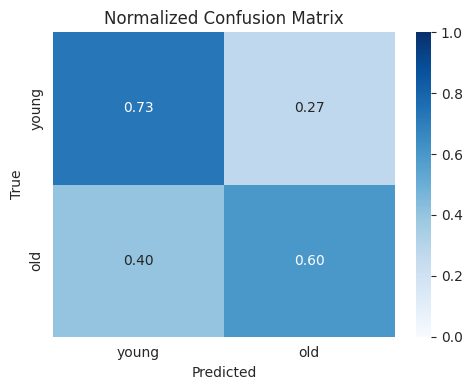

In [11]:
print(classification_report(results["y_true"], results["y_pred"], target_names=["young", "old"]))
cm = confusion_matrix(results["y_true"], results["y_pred"], normalize="true")
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=["young", "old"], yticklabels=["young", "old"])
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 7) ROC and calibration

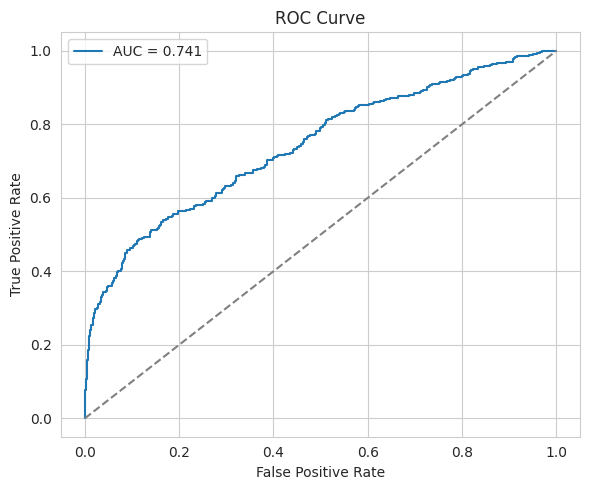

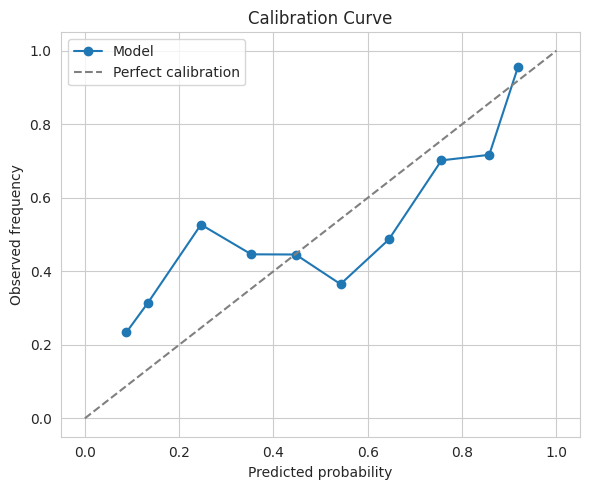

In [12]:
fpr, tpr, _ = roc_curve(results["y_true"], results["y_prob"])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

prob_true, prob_pred = calibration_curve(results["y_true"], results["y_prob"], n_bins=10, strategy="uniform")
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0,1], [0,1], "--", color="gray", label="Perfect calibration")
plt.title("Calibration Curve")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.legend()
plt.tight_layout()
plt.show()

## 8) Confidence distribution and entropy

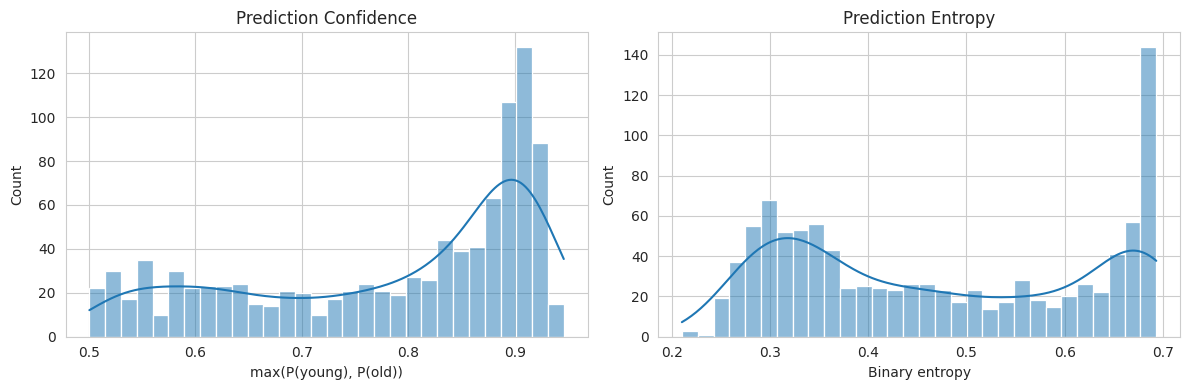

In [13]:
confidence = np.maximum(results["y_prob"], 1 - results["y_prob"])
entropy = robust_binary_entropy(results["y_prob"])

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(confidence, bins=30, kde=True, ax=axes[0])
axes[0].set_title("Prediction Confidence")
axes[0].set_xlabel("max(P(young), P(old))")

sns.histplot(entropy, bins=30, kde=True, ax=axes[1])
axes[1].set_title("Prediction Entropy")
axes[1].set_xlabel("Binary entropy")

plt.tight_layout()
plt.show()

## 9) Age-bucket performance

In [14]:
df = pd.DataFrame({
    "age": results["ages"],
    "true": results["y_true"],
    "pred": results["y_pred"],
    "prob_old": results["y_prob"],
    "confidence": np.maximum(results["y_prob"], 1-results["y_prob"]),
})
df["bucket"] = df["age"].apply(age_bucket)

order = ["0-9","10-19","20-29","30-39","40-49","50-59","60-69","70+"]
bucket_df = (
    df.groupby("bucket")
      .apply(lambda g: pd.Series({
          "accuracy": (g["true"] == g["pred"]).mean(),
          "avg_confidence": g["confidence"].mean(),
          "count": len(g),
      }))
      .reset_index()
)
bucket_df["bucket"] = pd.Categorical(bucket_df["bucket"], categories=order, ordered=True)
bucket_df = bucket_df.sort_values("bucket")
bucket_df

/tmp/ipykernel_2013/3000778606.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,bucket,accuracy,avg_confidence,count
0,0-9,0.658915,0.753568,129.0
1,10-19,0.787879,0.791605,66.0
2,20-29,0.745763,0.772518,295.0
3,30-39,0.367647,0.766983,204.0
4,40-49,0.578947,0.793419,95.0
5,50-59,0.800000,0.829866,90.0
6,60-69,0.836735,0.804336,49.0
7,70+,0.875000,0.823758,72.0


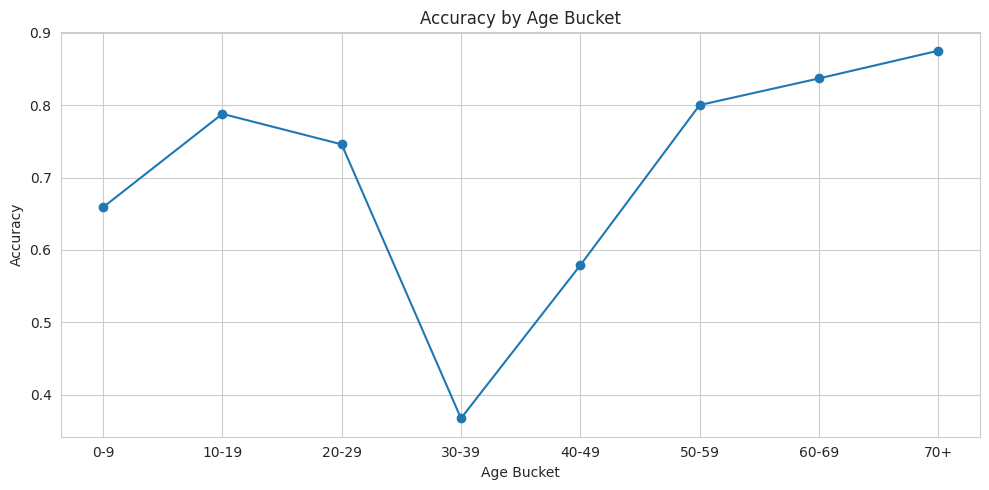

In [15]:
plt.figure(figsize=(10,5))
plt.plot(bucket_df["bucket"], bucket_df["accuracy"], marker="o")
plt.title("Accuracy by Age Bucket")
plt.xlabel("Age Bucket")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

## 10) Error analysis

In [16]:
df["correct"] = (df["true"] == df["pred"])
errors = df[~df["correct"]].copy()
errors = errors.sort_values(["confidence", "age"], ascending=[False, True])
display(errors.head(20))

# save the top errors for later comparison
errors.head(100).to_csv(OUTPUT_DIR / "top_100_errors.csv", index=False)

,age,true,pred,prob_old,confidence,bucket,correct
977,29,0,1,0.922224,0.922224,20-29,False
74,40,1,0,0.078513,0.921487,40-49,False
874,38,1,0,0.078604,0.921396,30-39,False
369,31,1,0,0.079309,0.920691,30-39,False
238,17,0,1,0.920617,0.920617,10-19,False
10,50,1,0,0.081402,0.918598,50-59,False
530,35,1,0,0.083287,0.916713,30-39,False
982,35,1,0,0.083670,0.916330,30-39,False
405,26,0,1,0.914647,0.914647,20-29,False
657,38,1,0,0.085631,0.914369,30-39,False


## 11) Robustness tests

Evaluate the checkpoint on perturbed images to measure how predictions shift under small distribution changes.

In [17]:
from PIL import Image, ImageFilter, ImageEnhance
import io

def jpeg_compress(img, quality=30):
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=quality)
    buf.seek(0)
    return Image.open(buf).convert("RGB")

def add_noise(img, sigma=0.08):
    arr = np.array(img).astype(np.float32) / 255.0
    arr = np.clip(arr + np.random.normal(0, sigma, arr.shape), 0, 1)
    return Image.fromarray((arr * 255).astype(np.uint8))

def blur_img(img, radius=2):
    return img.filter(ImageFilter.GaussianBlur(radius=radius))

def change_brightness(img, factor=0.7):
    return ImageEnhance.Brightness(img).enhance(factor)

def evaluate_on_images(model, images, labels, batch_size=64):
    tmp_records = [{"image": im, "age": int(label)} for im, label in zip(images, labels)]
    tmp_ds = FaceAgeDataset(tmp_records, transform=EVAL_TRANSFORM)
    tmp_loader = DataLoader(tmp_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    out = run_inference(model, tmp_loader)
    acc = accuracy_score(out["y_true"], out["y_pred"])
    return acc, out

raw_images = [r["image"].convert("RGB") for r in records]
raw_labels = np.array([age_to_label(r["age"]) for r in records])

robustness_rows = []
transforms_to_test = {
    "clean": lambda x: x,
    "jpeg_q30": lambda x: jpeg_compress(x, quality=30),
    "gaussian_noise": lambda x: add_noise(x, sigma=0.08),
    "blur_r2": lambda x: blur_img(x, radius=2),
    "brightness_0.7": lambda x: change_brightness(x, factor=0.7),
}

for name, fn in transforms_to_test.items():
    perturbed = [fn(img) for img in raw_images]
    acc, out = evaluate_on_images(model, perturbed, raw_labels)
    robustness_rows.append({
        "condition": name,
        "accuracy": acc,
        "avg_confidence": float(np.mean(np.maximum(out["y_prob"], 1 - out["y_prob"]))),
        "entropy": float(np.mean(robust_binary_entropy(out["y_prob"]))),
    })

robustness_df = pd.DataFrame(robustness_rows)
robustness_df

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

,condition,accuracy,avg_confidence,entropy
0,clean,0.561,0.782599,0.471063
1,jpeg_q30,0.536,0.783276,0.471843
2,gaussian_noise,0.480,0.779319,0.477305
3,blur_r2,0.593,0.784213,0.468910
4,brightness_0.7,0.536,0.782914,0.474621


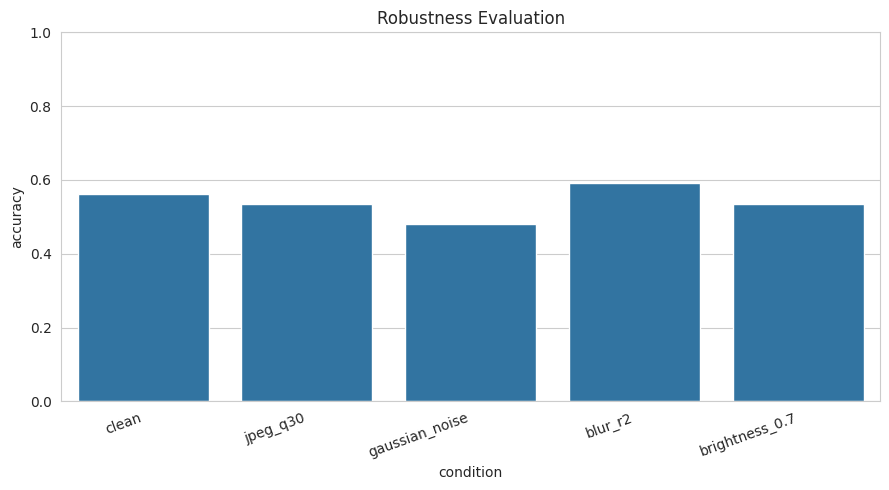

In [18]:
plt.figure(figsize=(9,5))
sns.barplot(data=robustness_df, x="condition", y="accuracy")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.title("Robustness Evaluation")
plt.tight_layout()
plt.show()

## 12) Save outputs

In [19]:
# predictions
pred_df = pd.DataFrame({
    "age": results["ages"],
    "true_label": results["y_true"],
    "pred_label": results["y_pred"],
    "prob_old": results["y_prob"],
    "confidence": np.maximum(results["y_prob"], 1 - results["y_prob"]),
    "entropy": robust_binary_entropy(results["y_prob"]),
    "bucket": [age_bucket(a) for a in results["ages"]],
})
pred_df.to_csv(OUTPUT_DIR / "predictions.csv", index=False)
bucket_df.to_csv(OUTPUT_DIR / "age_bucket_accuracy.csv", index=False)
robustness_df.to_csv(OUTPUT_DIR / "robustness.csv", index=False)

with open(OUTPUT_DIR / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved outputs to:", OUTPUT_DIR.resolve())

Saved outputs to: /content/phase2_outputs


In [20]:
import shutil
from google.colab import files

# Create a zip archive of the output directory
output_archive_path = shutil.make_archive(
    base_name=OUTPUT_DIR.name,  # The name of the archive (e.g., 'phase2_outputs')
    format='zip',
    root_dir=OUTPUT_DIR.parent, # The base directory to start archiving from (e.g., '/content')
    base_dir=OUTPUT_DIR.name    # The directory to archive relative to root_dir
)

print(f"Created archive: {output_archive_path}")

# Download the archive
files.download(output_archive_path)

Created archive: /content/phase2_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>